<a href="https://colab.research.google.com/github/ReleNthako/K-Means-Clustering-Synthetic-Data-Interactive-Lab/blob/main/k_means_Data_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

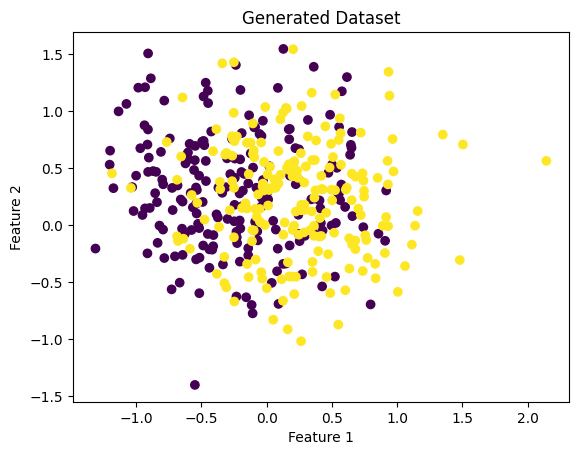

Accuracy: 0.67


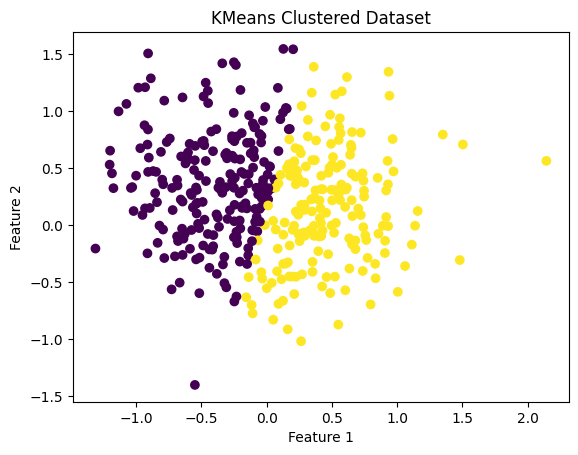

In [ ]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Define dataset parameters (you can experiment with these values)
N1 = 200  # Number of observations in class 1
N2 = 200  # Number of observations in class 2
d  = 10.0   # Distance between class centers
sigma1 = 0.5  # Dispersion (standard deviation) for class 1
sigma2 = 0.5  # Dispersion (standard deviation) for class 2

# Generate class center locations
x1_center = d / 2 * np.array([-1, 1])  # Class 1 center
x2_center = d / 2 * np.array([1, 1])   # Class 2 center

# Create feature matrix by adding noise to class center locations
noise1 = np.random.normal(scale=sigma1, size=(N1, 2))  # Noise for class 1
noise2 = np.random.normal(scale=sigma2, size=(N2, 2))  # Noise for class 2
nosie3 = np.random.n

X1 = x1_center + noise1  # Class 1 data points
X2 = x2_center + noise2  # Class 2 data points

# Combine data points from both classes
X = np.concatenate((X1, X2), axis=0)

# Create class labels (0 for class 1, 1 for class 2)
y = np.array([0] * N1 + [1] * N2)

# Visualize the generated dataset
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Generated Dataset")
plt.show()

# Apply KMeans clustering
n_clusters = 2  # Since we have two classes
kmeans = KMeans(n_clusters=n_clusters)
kmeans.fit(X)

# Get the cluster labels assigned by KMeans
kmeans_labels = kmeans.labels_

# Align KMeans labels with true class labels
aligned_labels = np.zeros_like(kmeans_labels)
for cluster in range(n_clusters):
    mask = (kmeans_labels == cluster)
    aligned_labels[mask] = np.argmax(np.bincount(y[mask]))

# Calculate accuracy
accuracy = np.sum(aligned_labels == y) / len(y)
print(f"Accuracy: {accuracy:.2f}")

# Visualize the clustered data
plt.scatter(X[:, 0], X[:, 1], c=kmeans_labels)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("KMeans Clustered Dataset")
plt.show()

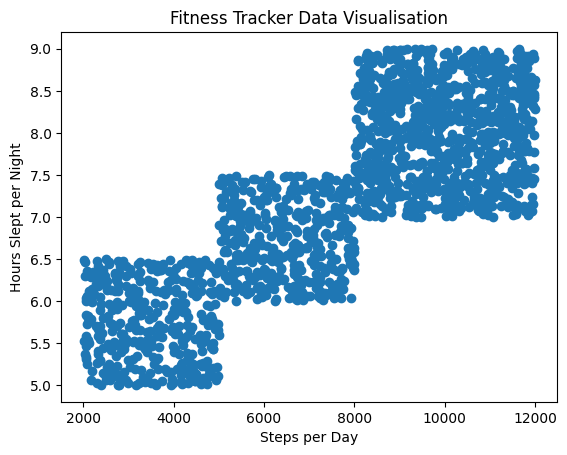

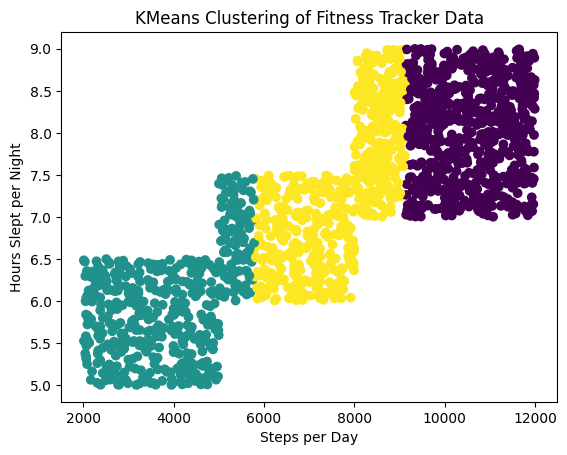

Cluster 0: Avg Steps = 10569.2, Avg Sleep = 8.0
Cluster 1: Avg Steps = 3901.9, Avg Sleep = 6.0
Cluster 2: Avg Steps = 7672.6, Avg Sleep = 7.3


In [ ]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Data Generation
# ----------------------------

# Choose number of users per cluster
Active_Users = np.random.randint(100, 1000)  # Active
Moderately_ActiveUsers = np.random.randint(100, 1000)  # Moderately active
Least_ActiveUsers = np.random.randint(100, 1000)  # Least active

# Ranges of steps per day for each user
# ----------------------------------------------

# Active users steps and  sleep per night
ActiveUsers_Steps = np.random.randint(8000, 12001, Active_Users)
ActiveUsers_Sleep = np.random.uniform(7, 9, Active_Users)

# Moderately active steps and sleep per night
ModActiveUsers_Steps = np.random.randint(5000, 8001, Moderately_ActiveUsers)
ModActiveUsers_Sleep = np.random.uniform(6, 7.5, Moderately_ActiveUsers)

# Least active steps  and sleep per night
LeastActiveUsers_Steps = np.random.randint(2000, 5001, Least_ActiveUsers)
LeastActiveUsers_Sleep = np.random.uniform(5, 6.5, Least_ActiveUsers)

# Combine all clusters into a single dataset
X = np.vstack((
    np.column_stack((ActiveUsers_Steps, ActiveUsers_Sleep)),
    np.column_stack((ModActiveUsers_Steps, ModActiveUsers_Sleep)),
    np.column_stack((LeastActiveUsers_Steps, LeastActiveUsers_Sleep))
))

# Visualize Data Generated
# ----------------------------

plt.scatter(X[:,0], X[:,1])
plt.xlabel("Steps per Day")
plt.ylabel("Hours Slept per Night")
plt.title("Fitness Tracker Data Visualisation")
plt.show()

==============================================

# Apply KMeans Clustering
# ----------------------------


kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X)
labels = kmeans.labels_

==============================================

# Visualize Clusters
# ----------------------------

plt.scatter(X[:,0], X[:,1], c=labels)
plt.xlabel("Steps per Day")
plt.ylabel("Hours Slept per Night")
plt.title("KMeans Clustering of Fitness Tracker Data")
plt.show()

# Analyze Clusters
# ----------------------------


for cluster in range(3):
    cluster_points = X[labels == cluster]
    avg_steps = cluster_points[:,0].mean()
    avg_sleep = cluster_points[:,1].mean()
    print(f"Cluster {cluster}: Avg Steps = {avg_steps:.1f}, Avg Sleep = {avg_sleep:.1f}")